# 01. Exploración de Datos (EDA)

En esta etapa, nos enfocaremos en entender la naturaleza del dataset de *California Housing*.
**Objetivo:** Obtener un entendimiento de los datos, de la industria, identificar anomalías, rangos, y relaciones clave.

### Instrucciones Generales:
1. **Carga los datos:** Lee el archivo `.csv` proveniente de la carpeta `data/raw/`
2. **Inspección:** Analisis exploratorio de datos, estructura, problemas de calidad: consistencia, sensibilidad, precision y completitud.
3. **Histogramas:** Genera histogramas para cada variable numérica usando `.hist()`.
4. **Visualización Geoespacial:** Crea un gráfico de dispersión (scatter plot) usando `longitude` y `latitude`. 
   - *Tip:* Utiliza el argumento `alpha=0.2` para ver lugares de alta densidad y `c` para colorear acorde a `median_house_value`.
5. **Correlaciones:** Calcula la matriz de correlación (usando `.corr()`) de todas las variables frente a `median_house_value` para encontrar las más prometedoras y graficos de dispercion entre las variables.
6. **Concluciones**: Redactar todos los hallazgos con un lenguaje de negocio y comunicativo.

In [2]:
# Escribe tu código aquí para explorar el dataset
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [10]:
raw_data = pd.read_csv(r'../data/interim/train_set.csv')

In [118]:
raw_data.sample(5)

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
16123,-117.95,34.03,33.0,1453.0,326.0,1609.0,319.0,3.7578,155800.0,<1H OCEAN
11890,-118.07,33.67,13.0,5126.0,711.0,2429.0,718.0,9.5268,437900.0,NEAR OCEAN
3293,-119.17,34.21,33.0,1039.0,256.0,1432.0,272.0,3.1103,143500.0,NEAR OCEAN
14464,-118.45,34.03,39.0,1657.0,402.0,931.0,363.0,3.7813,336300.0,<1H OCEAN
11288,-118.04,33.97,29.0,2376.0,700.0,1968.0,680.0,2.6082,162500.0,<1H OCEAN


In [12]:
raw_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16512 entries, 0 to 16511
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           16512 non-null  float64
 1   latitude            16512 non-null  float64
 2   housing_median_age  16512 non-null  float64
 3   total_rooms         16512 non-null  float64
 4   total_bedrooms      16344 non-null  float64
 5   population          16512 non-null  float64
 6   households          16512 non-null  float64
 7   median_income       16512 non-null  float64
 8   median_house_value  16512 non-null  float64
 9   ocean_proximity     16512 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.3+ MB


### Precision

In [13]:
#duplicados explicidos
duplicados = raw_data[raw_data.duplicated()]
print(f"Número de filas duplicadas: {duplicados.shape[0]}")

Número de filas duplicadas: 0


In [ ]:
#duplicados lógicos
#-----------------------------------------------------------------
#1. Misma Ubicacion 
dup_logicos_ubi = raw_data[
    raw_data.duplicated(subset=["longitude", "latitude"], keep=False)
]
print(dup_logicos_ubi.shape[0])


8966


In [15]:
dup_logicos_ubi = dup_logicos_ubi.sort_values(["longitude", "latitude"])
dup_logicos_ubi

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
4008,-124.18,40.78,37.0,1453.0,293.0,867.0,310.0,2.5536,70200.0,NEAR OCEAN
8862,-124.18,40.78,34.0,1592.0,364.0,950.0,317.0,2.1607,67000.0,NEAR OCEAN
8932,-124.18,40.79,40.0,1398.0,311.0,788.0,279.0,1.4668,64600.0,NEAR OCEAN
10032,-124.18,40.79,39.0,1836.0,352.0,883.0,337.0,1.7450,70500.0,NEAR OCEAN
4079,-124.17,40.80,52.0,1606.0,419.0,891.0,367.0,1.5850,75500.0,NEAR OCEAN
...,...,...,...,...,...,...,...,...,...,...
14030,-115.49,32.67,29.0,1523.0,440.0,1302.0,393.0,1.1311,84700.0,INLAND
318,-115.37,32.81,23.0,1458.0,294.0,866.0,275.0,2.3594,74300.0,INLAND
7189,-115.37,32.81,32.0,741.0,191.0,623.0,169.0,1.7604,68600.0,INLAND
13854,-115.37,32.82,14.0,1276.0,270.0,867.0,261.0,1.9375,80900.0,INLAND


In [ ]:
# Utilizaremos la version redondeada del ingreso, para encontrar filas similares que pueden tener poca variacion
raw_data['income_rounded'] = raw_data['median_income'].round(2)

# Ademas de longitud y latitud, utilizar la antiguedad e ingreso tambien para comparar
columnas_logicas = ['longitude', 'latitude', 'housing_median_age', 'income_rounded']
#------------------------------------------------------------------------
#2. Encontrar duplicados lógicos comparando las columnas logicas
duplicados_logicos = raw_data[raw_data.duplicated(subset=columnas_logicas, keep=False)]

if not duplicados_logicos.empty:
    print(f"--- Se encontraron {len(duplicados_logicos)} registros duplicados")
    print(duplicados_logicos.sort_values(by=columnas_logicas).head(10))
else:
    print("No hay duplicados.")

--- Se encontraron 10 registros duplicados
       longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
2065     -122.48     37.70                33.0       4492.0             NaN   
15747    -122.48     37.70                33.0       4167.0          1398.0   
4880     -122.40     37.72                47.0       1167.0           250.0   
9358     -122.40     37.72                47.0       1465.0           306.0   
744      -122.29     37.89                52.0        979.0           175.0   
13532    -122.29     37.89                52.0       2269.0           380.0   
995      -122.27     37.84                52.0       1503.0           298.0   
4684     -122.27     37.84                52.0       2224.0           437.0   
2991     -118.41     34.07                52.0       1202.0           142.0   
15670    -118.41     34.07                52.0       3562.0           394.0   

       population  households  median_income  median_house_value  \
2065       3477.0  

In [ ]:
# --- LIMPIEZA --- 
# Se podria mantener el último (mayor índice), considerando que es la misma ubicación pero existe una actualizacion
# de las otras columnas
data_sin_duplicados = raw_data.drop_duplicates(subset=columnas_logicas, keep='last').copy()

# Eliminamos la columna de redondeo de ambos DataFrames para mantener el set de datos limpio
data_sin_duplicados = data_sin_duplicados.drop(columns=['income_rounded'])
raw_data.drop(columns=['income_rounded'], inplace=True)

print(f"\n--- RESUMEN DE LIMPIEZA ---")
print(f"Registros originales: {len(raw_data)}")
print(f"Registros eliminados (versiones antiguas): {len(raw_data) - len(data_sin_duplicados)}")
print(f"Registros finales: {len(data_sin_duplicados)}")

### Completitud

In [35]:
bedroom_nulo = raw_data[raw_data["total_bedrooms"].isna()]
bedroom_nulo.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
99,-120.67,40.50,15.0,5343.0,NaN,2503.0,902.0,3.5962,85900.0,INLAND
194,-117.96,34.03,35.0,2093.0,NaN,1755.0,403.0,3.4115,150400.0,<1H OCEAN
249,-118.05,34.04,33.0,1348.0,NaN,1098.0,257.0,4.2917,161200.0,<1H OCEAN
267,-118.88,34.17,15.0,4260.0,NaN,1701.0,669.0,5.1033,410700.0,<1H OCEAN
438,-117.87,33.62,8.0,1266.0,NaN,375.0,183.0,9.8020,500001.0,<1H OCEAN


In [36]:
bedroom_nulo.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,168.000000,168.000000,168.000000,168.000000,0.0,168.000000,168.000000,168.000000,168.000000
mean,-119.510774,35.575774,28.833333,2488.708333,NaN,1444.214286,505.690476,3.715555,198711.339286
std,1.994297,2.100587,12.189947,1773.844464,NaN,1047.603231,403.946845,1.934817,110405.271434
min,-124.130000,32.660000,4.000000,154.000000,NaN,37.000000,16.000000,0.852700,45800.000000
25%,-121.790000,33.975000,18.000000,1277.250000,NaN,772.500000,254.750000,2.517550,117525.000000
50%,-118.550000,34.250000,29.500000,2022.500000,NaN,1138.500000,404.500000,3.310350,170850.000000
75%,-118.065000,37.582500,38.000000,3345.000000,NaN,1870.250000,627.500000,4.368775,259525.000000
max,-114.590000,40.920000,52.000000,11709.000000,NaN,7604.000000,3589.000000,15.000100,500001.000000


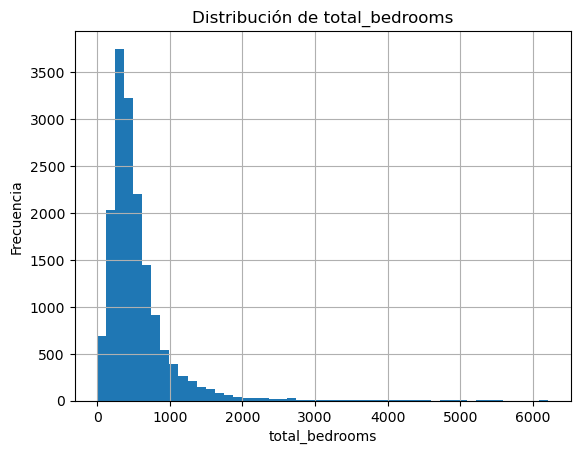

In [37]:
raw_data["total_bedrooms"].hist(bins=50)
plt.xlabel("total_bedrooms")
plt.ylabel("Frecuencia")
plt.title("Distribución de total_bedrooms")
plt.show()

In [38]:
kurtosis = raw_data["total_bedrooms"].kurt()
print(f"Curtosis: {kurtosis}")

Curtosis: 21.34913348992443


Como no es una distribucion normal, si no existen datos extremos a la derecha, para no alterar la distribucion se podria completar los datos null con la mediana o incluso se podrian borrar ya que representan un 1,02% del total de los datos.

In [39]:
# Calcular la mediana
mediana = raw_data["total_bedrooms"].median()
print(f'La mediana del conjunto de datos es:{mediana}')

La mediana del conjunto de datos es:434.0


In [40]:
# Porcentaje de nulos
porcentaje_nulo = bedroom_nulo.shape[0]/raw_data.shape[0]
print(f'El porcentaje de nulos representa: {round(porcentaje_nulo*100,2)}%')

El porcentaje de nulos representa: 1.02%


### Histogramas

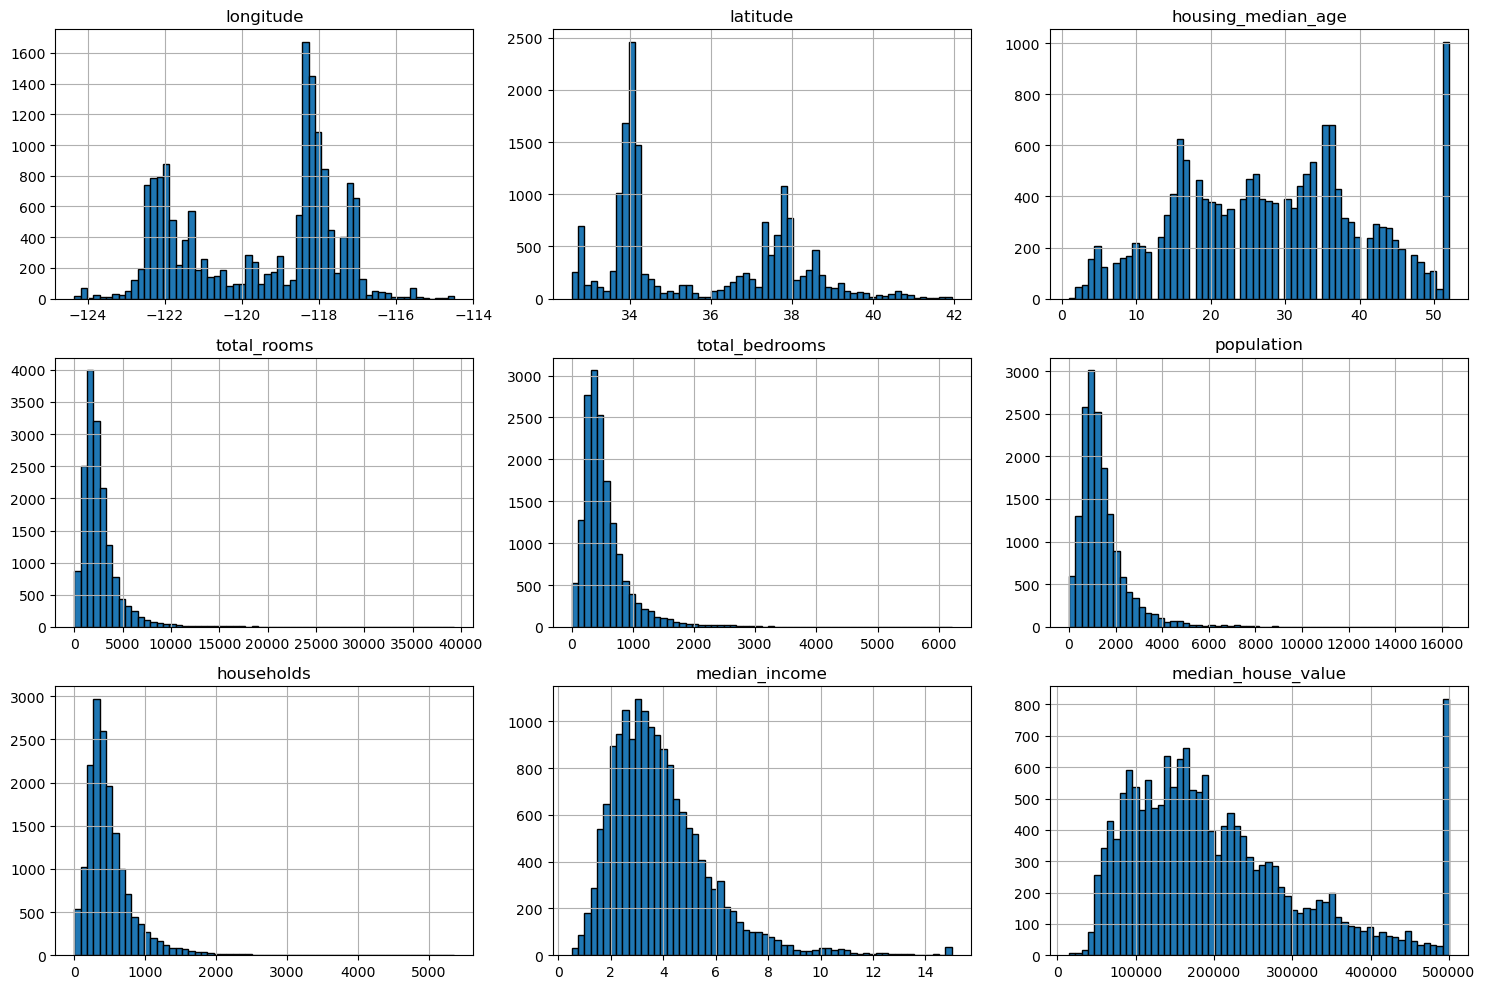

In [41]:
raw_data.hist(bins=60, figsize=(15,10), edgecolor="black")
plt.tight_layout()
plt.show()

In [42]:
raw_data.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,16512.000000,16512.000000,16512.000000,16512.000000,16344.000000,16512.000000,16512.000000,16512.000000,16512.000000
mean,-119.573125,35.637746,28.577156,2639.402798,538.949094,1425.513929,499.990189,3.870428,206333.518653
std,2.000624,2.133294,12.585738,2185.287466,423.862079,1094.795467,382.865787,1.891936,115314.047529
min,-124.350000,32.550000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.000000,296.000000,787.000000,279.000000,2.562500,119200.000000
50%,-118.510000,34.260000,29.000000,2125.000000,434.000000,1167.000000,408.000000,3.538500,179200.000000
75%,-118.010000,37.720000,37.000000,3154.000000,645.000000,1726.000000,603.000000,4.750000,263925.000000
max,-114.490000,41.950000,52.000000,39320.000000,6210.000000,16305.000000,5358.000000,15.000100,500001.000000


### Sensibilidad

En base a los histogramas existen valores atipicos hacia la derecha de los graficos de barras, se analizan las variables housing_median_age, median_income, median_house_value

En el caso de housing_median_age, median_house_value se muestran barras de muchos valores en los puntos maximos (52 y 500001), lo que puede significar que se trata de un limite en los valores de recolección mas que outliers, es decir cualquier antiguedad mayor a 52 años se cataloga con 52.

In [43]:
# PARA median_income existen valores atipicos hacia la derecha
# los cuales pueden ser consistentes tomando en cuenta que las
# personas con muchos ingresos son minimas en comparacion con la gente
# con ingresos promedio, pero igual se puede utilizar quartiles
Q1 = raw_data['median_income'].quantile(0.25)
Q3 = raw_data['median_income'].quantile(0.75)
IQR = Q3 - Q1
limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

outliers = raw_data[(raw_data['median_income'] < limite_inferior) | (raw_data['median_income'] > limite_superior)]

print(f"Límite superior para ingresos: {limite_superior:.2f}")
print(f"Cantidad de outliers detectados en ingresos: {len(outliers)}")

Límite superior para ingresos: 8.03
Cantidad de outliers detectados en ingresos: 537


Otras variables con valores extremos que podrian ser atipicos

In [44]:
bedrooms_altos = raw_data[raw_data["total_bedrooms"] > 5000]
bedrooms_altos.shape[0]

6

In [45]:
bedrooms_altos

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
862,-117.20,33.58,2.0,30450.0,5033.0,9419.0,3197.0,4.5936,174300.0,<1H OCEAN
3616,-121.53,38.48,5.0,27870.0,5027.0,11935.0,4855.0,4.8811,212200.0,INLAND
5442,-118.44,33.98,21.0,18132.0,5419.0,7431.0,4930.0,5.3359,500001.0,<1H OCEAN
5825,-117.74,33.89,4.0,37937.0,5471.0,16122.0,5189.0,7.4947,366300.0,<1H OCEAN
11113,-117.78,34.03,8.0,32054.0,5290.0,15507.0,5050.0,6.0191,253900.0,<1H OCEAN
16141,-121.44,38.43,3.0,39320.0,6210.0,16305.0,5358.0,4.9516,153700.0,INLAND


In [46]:
bedrooms_altos["bedrooms_per_room"] = (
    bedrooms_altos["total_bedrooms"] / bedrooms_altos["total_rooms"]
)

C:\Users\DETPC\AppData\Local\Temp\ipykernel_24296\3949270819.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  bedrooms_altos["bedrooms_per_room"] = (


In [47]:
bedrooms_altos

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity,bedrooms_per_room
862,-117.20,33.58,2.0,30450.0,5033.0,9419.0,3197.0,4.5936,174300.0,<1H OCEAN,0.165287
3616,-121.53,38.48,5.0,27870.0,5027.0,11935.0,4855.0,4.8811,212200.0,INLAND,0.180373
5442,-118.44,33.98,21.0,18132.0,5419.0,7431.0,4930.0,5.3359,500001.0,<1H OCEAN,0.298864
5825,-117.74,33.89,4.0,37937.0,5471.0,16122.0,5189.0,7.4947,366300.0,<1H OCEAN,0.144213
11113,-117.78,34.03,8.0,32054.0,5290.0,15507.0,5050.0,6.0191,253900.0,<1H OCEAN,0.165034
16141,-121.44,38.43,3.0,39320.0,6210.0,16305.0,5358.0,4.9516,153700.0,INLAND,0.157935


### Visualización Geoespacial

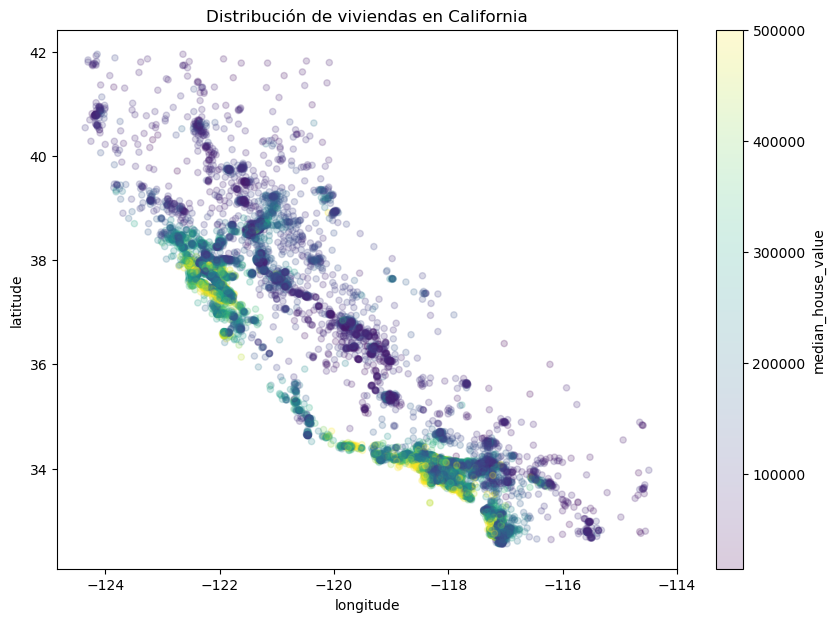

In [48]:
raw_data.plot(
    kind="scatter",
    x="longitude",
    y="latitude",
    alpha=0.2,
    c="median_house_value",
    cmap="viridis",
    colorbar=True,
    figsize=(10,7)
)

plt.title("Distribución de viviendas en California")
plt.show()

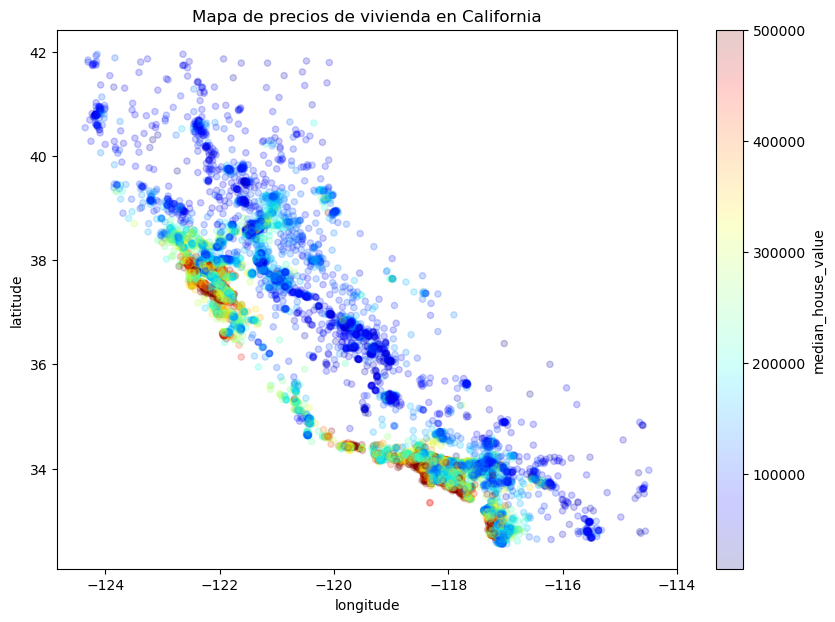

In [49]:
raw_data.plot(
    kind="scatter",
    x="longitude",
    y="latitude",
    alpha=0.2,
    c="median_house_value",
    cmap="jet",
    colorbar=True,
    figsize=(10,7)
)

plt.title("Mapa de precios de vivienda en California")
plt.show()

### Correlacion

In [50]:
correlaciones = raw_data.corr(numeric_only=True)["median_house_value"].sort_values(ascending=False)
print(correlaciones)

median_house_value    1.000000
median_income         0.688380
total_rooms           0.137455
housing_median_age    0.102175
households            0.071426
total_bedrooms        0.054635
population           -0.020153
longitude            -0.050859
latitude             -0.139584
Name: median_house_value, dtype: float64


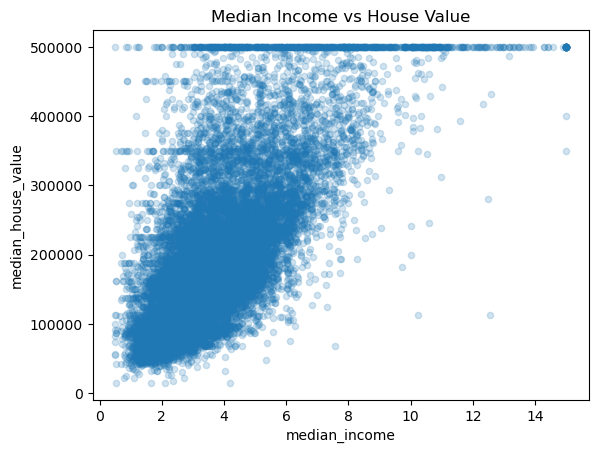

In [51]:
raw_data.plot(
    kind="scatter",
    x="median_income",
    y="median_house_value",
    alpha=0.2
)
plt.title("Median Income vs House Value")
plt.show()

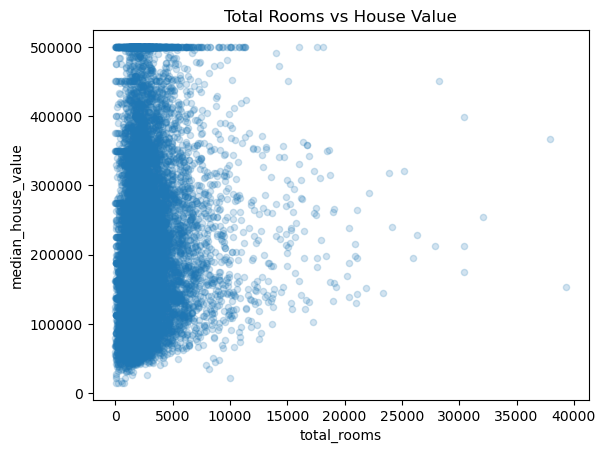

In [52]:
raw_data.plot(
    kind="scatter",
    x="total_rooms",
    y="median_house_value",
    alpha=0.2
)
plt.title("Total Rooms vs House Value")
plt.show()

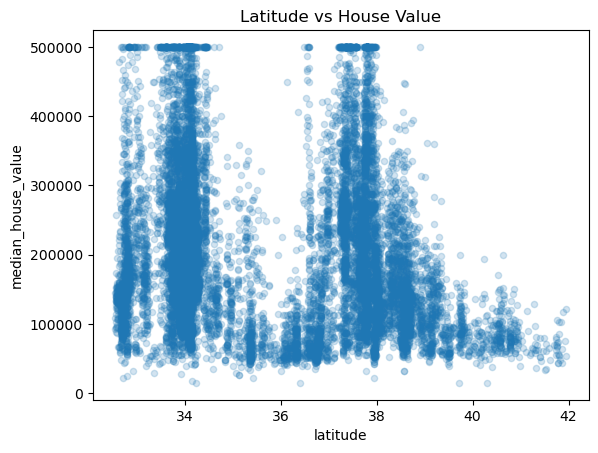

In [53]:
raw_data.plot(
    kind="scatter",
    x="latitude",
    y="median_house_value",
    alpha=0.2
)
plt.title("Latitude vs House Value")
plt.show()

### Conclusiones

**Precisión - Duplicados**

- En el dataset no existen duplicados explicitos, pero se debe en la limpieza buscarlos y eliminarlos, pues puede existir algun problema en la recolección.

- Duplicados lógicos se los encontro comparando la ubicacion exacta y concidencias entre filas con la antiguedad e ingresos (redondeados), pues al solo tener 2 decimales en latitud y longitud de acuerdo a internet la zona chocaria con otra a 1.1 Km2, lo que significa que si una fila tiene la misma ubicacion y los mismos ingresos y antiguedad, se trata de un duplicado el cual de seguro es una actualización de datos

**Completitud - Valores ausentes**

- En los datos solo la columna total_bedrooms, tiene valores nulos. Al realizar un analisis se encuentra que estos valores son de tipo MCAR. Se podrian ignorar (Eliminar), ya que solo representan un 1% del total de datos. Otra opcion es rellenarnos utilizando la mediana, ya que la distribución no es normal y para evitar que la distribucion de datos cambie. 

**Sensibilidad - Outliers**

- Utilizando los histogramas, se aprecian una acumulacion de valores extremos en la antiguedad y valor medio, pero analizando los datos de estas columnas se puede apreciar que estos valores se deben a un aparente limite. Pues no existen valores superiores a 52 años y 500001 valor, pero existe una gran cantidad de valores con estos valores. Es decir una propiedad de 60 años de antiguedad el sistema de recolección los recolecta como 52.
    1. Como el objetivo del proyecto es predecir el precio y no solo decir si es barata, media y cara una propiedad es mejor eliminar estos registros. Sino el modelo aprenderá mal para el una casa de $1,000,000 "vale" $500,000.
    2. En el caso de la antiguedad, para evitar eliminar registros se podria categorizar la variable entre nueva, media, vieja, de esta manera ya no existe una relacion numerica sesgada

- Para el caso de los ingresos (median_income), si se tiene pocos valores extremos, esto se puede explicar tomando en cuenta la sociedad, las personas con fuerte poder adquisitivo es una minoria en comparación con las personas con ingresos promedio. Se utiliza el rango intercuatilico para identificar outliers. Para poder tratar estos valores se tienen dos opciones: 
    1. Reemplazar valores extremos con un valor limite
    2. Aplicar logaritmo para 'encoger' la cola
    3. Eliminar los valores. (Se introduciria sesgo ya que no se tendrian datos importantes sobre personas con altos ingresos, los cuales ya son pocos.)

- Existen otroas columnas que en el histograma se puede observar que tienen grandes colas derechas, para ellas se debera aplicar el criterio del rango intercuartilico, para eliminar valores poco realistas, los cuales pueden ser verdaderos pero afectan significativamente al modelo por las magnitudes

**Consistencia** 
- Las columnas: housing_median_age, total_rooms, total_bedrooms, population, households. Son de tipo float, pero estas no presentan valores decimales, son valores exactos. Seria prudente transformarlos a int64 para ahorar memoria

**Correlacion**
- La variable median_income, es la unica que presenta una correlacion moderada con la variable objetivo, esta variable puede ser utiliza para segmentar el dataset para realizar entrenamiento y test.

**Ubicacion**
- Las propiedades mas cercanas a la costa son los mas costosas.